# 7.1 Otimizacao regional -- 1 conjunto de parametros por cluster (ou por PR inteiro)

Estrategia diferente da etapa 7: em vez de calibrar um conjunto de parametros **por
municipio** (391 calibracoes, cada uma ajustada so aos 10 anos daquele municipio), aqui
calibramos **um unico conjunto de parametros por grupo** (um cluster inteiro, ou o Parana
inteiro), otimizando o RMSE agregado de todos os municipios x safras do grupo
simultaneamente. Isso favorece um parametro set generalizavel, pensado pra inferencia em
qualquer ponto do grupo depois -- ao custo de nao encaixar perfeitamente em nenhum
municipio especifico (o que e o objetivo: evitar overfit na serie curta de cada
municipio).

## Diferencas importantes em relacao a etapa 7

- **Amostragem por grupo**: agregar um cluster inteiro (ex: 191 municipios x 10 anos =
  1910 simulacoes por avaliacao do NLOPT) e computacionalmente inviavel em milhares de
  avaliacoes. `N_POINTS_PER_GROUP` amostra um subconjunto representativo de municipios por
  grupo (padrao 30, mesma ordem de grandeza da amostragem ja usada no Morris Screen).
- **Funcao objetivo tolerante a falhas**: com so ~10 amostras por municipio (etapa 7), uma
  unica simulacao invalida podia zerar a tentativa (penalidade `1e10`) sem grande problema.
  Com centenas de amostras agregadas, exigir 100% de sucesso travaria a otimizacao quase
  sempre -- aqui a funcao objetivo (`objective_function_regional`,
  `util/NLOPT_regional_soja_pr.py`) tolera ate `FAILURE_TOLERANCE` (20%) de falhas antes de
  penalizar.
- **Criterio de parada**: o mesmo desta demanda -- interrompe a etapa hierarquica quando o
  **RMSE do grupo inteiro < 100 kg/ha**.
- Os parametros binarios instaveis do WOFOST (`IDSL`, `IAIRDU`, `IOX`) continuam excluidos
  do conjunto otimizavel (mesmo motivo da etapa 7).

## Escolha do nivel de agregacao

- `'cluster'`: um conjunto de parametros por cluster climatico (4 grupos, usa o ranking de
  sensibilidade ja calculado por cluster na etapa 6).
- `'estado'`: um unico conjunto de parametros pra todo o Parana (usa o ranking de
  sensibilidade **geral**, `SA_MORRIS_overall_summary.csv`, tambem ja salvo pela etapa 6).


In [1]:
import glob
import json
import os
import sys

import nlopt
import pandas as pd

sys.path.append(os.path.join(os.getcwd(), 'util'))
from util.SensitivityAnalyzer_soja_pr import SoyNetCDFDataLoader
from util.NLOPT_regional_soja_pr import SoyWOFOSTRegionalOptimizerPR, load_overall_ranking
from util.NLOPT_soja_pr import load_cluster_params_from_ranking
from util.utils_soja_pr import setup_paths_soja_pr

paths = setup_paths_soja_pr()


## Configuracao


In [2]:
# 'cluster': 1 conjunto de parametros por cluster climatico.
# 'estado':  1 unico conjunto de parametros pra todo o Parana.
NIVEL_AGREGACAO = 'estado'

# Quantos municipios amostrar por grupo (por cluster, ou no total se 'estado').
# Cada avaliacao do NLOPT roda o WOFOST N_POINTS_PER_GROUP x 10 safras vezes --
# manter esse numero baixo o suficiente pra rodar em tempo razoavel.
N_POINTS_PER_GROUP = 300*0.7

# Orcamento de avaliacoes do NLOPT. Como cada avaliacao aqui e ~N_POINTS_PER_GROUP
# vezes mais cara que na etapa 7 (por municipio), usar um valor menor que os 3000
# da etapa 7 costuma ser necessario pra terminar em tempo razoavel.
MAX_EVAL = 1500

# Reoptimiza grupos que ja tem resultado salvo (OPT_REGIONAL_group..._summary.json)?
FORCE_RERUN = False

RANDOM_SEED = 42


## Montar os grupos (com amostragem)


In [3]:
import random
random.seed(RANDOM_SEED)

nc_loader = SoyNetCDFDataLoader(paths['COMPLETO'])

arquivos_por_cluster = {}
for nc_file in nc_loader.nc_files:
    info = nc_loader.get_point_info(nc_file)
    arquivos_por_cluster.setdefault(info['cluster_id'], []).append(nc_file)

if NIVEL_AGREGACAO == 'cluster':
    grupos = {}
    for cluster_id, arquivos in arquivos_por_cluster.items():
        amostra = random.sample(arquivos, min(N_POINTS_PER_GROUP, len(arquivos)))
        grupos[cluster_id] = amostra
elif NIVEL_AGREGACAO == 'estado':
    # Amostragem estratificada: pega uma fatia proporcional de cada cluster, pra manter
    # a diversidade climatica do estado no grupo unico.
    total_municipios = sum(len(v) for v in arquivos_por_cluster.values())
    amostra_estado = []
    for cluster_id, arquivos in arquivos_por_cluster.items():
        n_cluster = max(1, round(N_POINTS_PER_GROUP * len(arquivos) / total_municipios))
        amostra_estado.extend(random.sample(arquivos, min(n_cluster, len(arquivos))))
    grupos = {'PR': amostra_estado}
else:
    raise ValueError(f"NIVEL_AGREGACAO deve ser 'cluster' ou 'estado', recebido: {NIVEL_AGREGACAO!r}")

for label, arquivos in grupos.items():
    n_amostras_estimadas = len(arquivos) * 10
    print(f"Grupo {label}: {len(arquivos)} municipios amostrados (~{n_amostras_estimadas} amostras municipio-safra por avaliacao do NLOPT)")


Encontrados 392 arquivos NetCDF
Grupo PR: 210 municipios amostrados (~2100 amostras municipio-safra por avaliacao do NLOPT)


## Carregar o ranking de parametros por grupo


In [4]:
group_params_by_label = {}

if NIVEL_AGREGACAO == 'cluster':
    ranking_json_path = os.path.join(paths['RESULTS'], 'SA_ranking_by_cluster.json')
    cluster_params = load_cluster_params_from_ranking(ranking_json_path, top_n=44)
    for cluster_id in grupos:
        if cluster_id not in cluster_params:
            print(f"[aviso] Cluster {cluster_id}: sem ranking de sensibilidade, pulando.")
            continue
        group_params_by_label[cluster_id] = cluster_params[cluster_id]
else:
    overall_csv_path = os.path.join(paths['RESULTS'], 'SA_MORRIS_overall_summary.csv')
    group_params_by_label['PR'] = load_overall_ranking(overall_csv_path, top_n=44)

for label, params in group_params_by_label.items():
    print(f"Grupo {label}: {len(params)} parametros a calibrar")


Grupo PR: 44 parametros a calibrar


## Rodar a otimizacao regional


In [7]:
optimizer = SoyWOFOSTRegionalOptimizerPR(
    paths=paths,
    nc_loader=nc_loader,
    cluster_params={},  # nao usado neste modo; optimize_group recebe os parametros direto
    algorithm=nlopt.LN_BOBYQA,
    max_eval=MAX_EVAL,
)


In [ ]:

resultados = []
for label, arquivos in grupos.items():
    if label not in group_params_by_label:
        continue

    summary_path = os.path.join(paths['OPTIMIZATION'], f"OPT_REGIONAL_group{label}_summary.json")
    if not FORCE_RERUN and os.path.exists(summary_path):
        print(f"Grupo {label}: ja otimizado, reaproveitando resultado salvo ({summary_path}).")
        with open(summary_path) as f:
            resultados.append(json.load(f))
        continue

    resultado = optimizer.optimize_group(arquivos, label, group_params_by_label[label])
    if resultado is not None:
        resultados.append({
            'group_label': resultado['group_label'],
            'n_municipios': resultado['n_municipios'],
            'n_samples': resultado['n_samples'],
            'rmse_aggregated': resultado['rmse_aggregated'],
            'stopped_early': resultado['stopped_early'],
        })

print("\nResumo final:")
for r in resultados:
    print(f"  Grupo {r['group_label']}: RMSE={r['rmse_aggregated']:.2f} kg/ha, "
          f"{r['n_municipios']} municipios, {r['n_samples']} amostras, parada antecipada={r['stopped_early']}")



🌎 OTIMIZACAO REGIONAL -- Grupo 'PR' (210 municipios)
📦 Preparando amostras de todos os municipios do grupo...


[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'


📅 Amostras (municipio x safra) validas: 2063

🔧 Iniciando otimizacao hierarquica (9 etapas, 44 parametros)


[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has no attribute 'add_variable'
[ERROR] - Erro na simulação: 'NoneType' object has n

   ✅ Etapa 1/9: RMSE regional = 1096.87 kg/ha (51840.7s)
   ✅ Etapa 2/9: RMSE regional = 1070.77 kg/ha (38394.7s)
   ✅ Etapa 3/9: RMSE regional = 979.50 kg/ha (44797.2s)
   ✅ Etapa 4/9: RMSE regional = 975.30 kg/ha (36998.9s)
   ✅ Etapa 5/9: RMSE regional = 976.18 kg/ha (43618.6s)
   ✅ Etapa 6/9: RMSE regional = 960.72 kg/ha (62727.9s)
   ✅ Etapa 7/9: RMSE regional = 997.39 kg/ha (117864.2s)
   ✅ Etapa 8/9: RMSE regional = 974.62 kg/ha (138281.0s)
   ✅ Etapa 9/9: RMSE regional = 973.90 kg/ha (78959.3s)

📈 Calculando metricas por municipio/ano com os parametros do grupo...
   💾 Parametros: d:\_py\AgroIA_prod\output\soja_pr\Optimization\OPT_REGIONAL_groupPR_params.csv
   💾 Metricas anuais: d:\_py\AgroIA_prod\output\soja_pr\Optimization\OPT_REGIONAL_groupPR_yearly_metrics.csv
   💾 Resumo: d:\_py\AgroIA_prod\output\soja_pr\Optimization\OPT_REGIONAL_groupPR_summary.json

🎉 Grupo 'PR' Completo! RMSE regional: 973.90 kg/ha | Tempo: 614976.2s


Resumo final:
  Grupo PR: RMSE=973.90 kg/ha, 210 

## Validacao fora da amostra (holdout)

Testa se o conjunto de parametros regional generaliza de verdade: aplica os parametros
calibrados de cada grupo (sem recalibrar nada) aos municipios que **nao** entraram na
amostra usada para calibrar (`N_POINTS_PER_GROUP`), e compara simulado x observado so
nesses municipios "nunca vistos" pelo otimizador.

Essa e a validacao que importa -- o RMSE de calibracao (celula anterior) mede o quao bem
o parametro set se encaixa na propria amostra usada pra ajusta-lo; o holdout mede se ele
serve pra inferencia em qualquer ponto do grupo, que e o objetivo desta estrategia.


In [5]:
def carregar_parametros_grupo(label):
    params_path = os.path.join(paths['OPTIMIZATION'], f"OPT_REGIONAL_group{label}_params.csv")
    if not os.path.exists(params_path):
        return None
    df = pd.read_csv(params_path)
    return df.iloc[0].drop(['group_label', 'n_municipios']).to_dict()


holdout_por_grupo = {}
for label, arquivos_amostrados in grupos.items():
    if NIVEL_AGREGACAO == 'cluster':
        todos_do_grupo = arquivos_por_cluster.get(label, [])
    else:  # 'estado' -- o grupo unico cobre todos os municipios do PR
        todos_do_grupo = nc_loader.nc_files

    amostrados_set = set(arquivos_amostrados)
    holdout = [f for f in todos_do_grupo if f not in amostrados_set]
    holdout_por_grupo[label] = holdout
    print(f"Grupo {label}: {len(arquivos_amostrados)} usados na calibracao, {len(holdout)} de fora (holdout)")


Grupo PR: 210 usados na calibracao, 182 de fora (holdout)


In [8]:
df_validacao_list = []

for label, arquivos_holdout in holdout_por_grupo.items():
    params_grupo = carregar_parametros_grupo(label)
    if params_grupo is None:
        print(f"[pulado] Grupo {label}: sem parametros calibrados salvos ainda (rode a celula de otimizacao antes).")
        continue
    if not arquivos_holdout:
        print(f"[aviso] Grupo {label}: nenhum municipio de fora da amostra para validar.")
        continue

    print(f"\nValidando grupo {label} em {len(arquivos_holdout)} municipios de fora da amostra...")

    for nc_file in arquivos_holdout:
        point_info, weather_df = nc_loader.load_point_data(nc_file)
        years_data = optimizer.prepare_multiyear_context(point_info, weather_df, point_info['point_id'])

        if len(years_data) == 0:
            continue

        metrics = optimizer._calculate_yearly_metrics(params_grupo, years_data)
        metrics.insert(0, 'point_id', point_info['point_id'])
        metrics.insert(1, 'group_label', label)
        df_validacao_list.append(metrics)

        for yd in years_data:
            if os.path.exists(yd['agro_temp_file']):
                os.remove(yd['agro_temp_file'])

df_validacao = pd.concat(df_validacao_list, ignore_index=True) if df_validacao_list else pd.DataFrame()
df_validacao = df_validacao.dropna(subset=['dyield_obs', 'dyield_sim'])
print(f"\nTotal de pares observado/simulado em municipios de fora da amostra: {len(df_validacao)}")



Validando grupo PR em 182 municipios de fora da amostra...

Total de pares observado/simulado em municipios de fora da amostra: 1781


In [9]:
import numpy as np

obs = df_validacao['dyield_obs'].values
sim = df_validacao['dyield_sim'].values

rmse_holdout = np.sqrt(np.mean((sim - obs) ** 2))
mae_holdout = np.mean(np.abs(sim - obs))
bias_holdout = np.mean(sim - obs)
r2_holdout = np.corrcoef(obs, sim)[0, 1] ** 2

print("Metricas de validacao fora da amostra (holdout):")
print(f"  RMSE: {rmse_holdout:.2f} kg/ha")
print(f"  MAE:  {mae_holdout:.2f} kg/ha")
print(f"  Bias: {bias_holdout:+.2f} kg/ha (positivo = modelo superestima)")
print(f"  R²:   {r2_holdout:.3f}")


Metricas de validacao fora da amostra (holdout):
  RMSE: 1024.82 kg/ha
  MAE:  769.29 kg/ha
  Bias: -168.90 kg/ha (positivo = modelo superestima)
  R²:   0.011


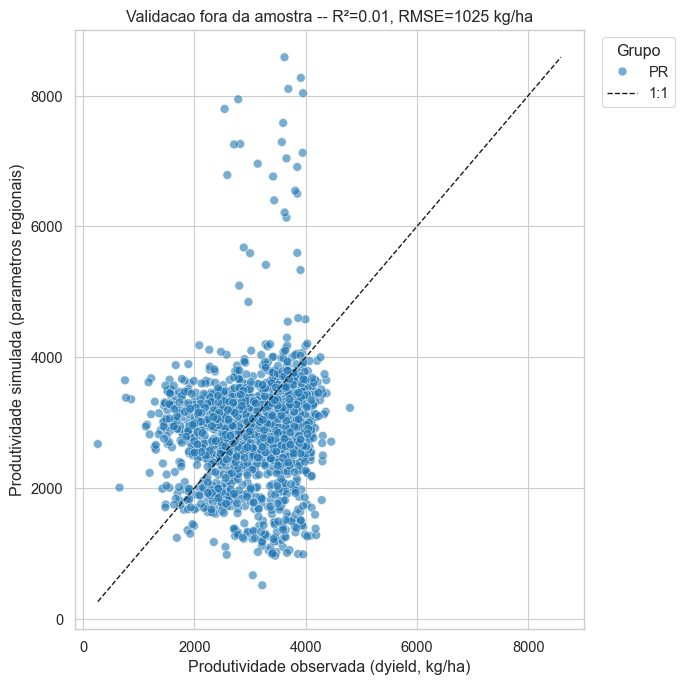

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_validacao, x='dyield_obs', y='dyield_sim', hue='group_label',
                 palette='tab10', alpha=0.6, s=40)

lim_min = min(df_validacao['dyield_obs'].min(), df_validacao['dyield_sim'].min())
lim_max = max(df_validacao['dyield_obs'].max(), df_validacao['dyield_sim'].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1, label='1:1')

plt.xlabel('Produtividade observada (dyield, kg/ha)')
plt.ylabel('Produtividade simulada (parametros regionais)')
plt.title(f'Validacao fora da amostra -- R²={r2_holdout:.2f}, RMSE={rmse_holdout:.0f} kg/ha')
plt.legend(title='Grupo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
validacao_path = os.path.join(paths['OPTIMIZATION'], 'validacao_holdout_regional.csv')
df_validacao.to_csv(validacao_path, index=False)
print(f"Validacao holdout salva em: {validacao_path}")
